<a href="https://colab.research.google.com/github/Muskanyada/Crime_Prediction/blob/main/crime_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("/content/Delhi Accident Data.csv")

print("Original Dataset Shape:", df.shape)

# Remove Extra Spaces from Column Names
# Remove leading and trailing spaces from column names
df.columns = df.columns.str.strip()


# Remove 'Unnamed' Columns (If They Exist)
# Identify columns that start with 'Unnamed'
unnamed_cols = [col for col in df.columns if col.startswith('Unnamed')]

# Drop them only if they exist
if len(unnamed_cols) > 0:
    df.drop(columns=unnamed_cols, inplace=True)
    print("Removed Unnamed columns:", unnamed_cols)
else:
    print("No Unnamed columns found.")


# Remove Extra Spaces from String Values
# Remove leading and trailing spaces from all string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()


# Drop Other Unwanted Columns (If Any)
# Add column names here that you want to remove manually
columns_to_drop = ['Sno']   # Example column

df.drop(columns=columns_to_drop, errors='ignore', inplace=True)


# Handle Missing Values
print("\nMissing Values Before Cleaning:")
print(df.isnull().sum())

# Fill missing numeric values with 0
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(0)

# Fill missing categorical values with 'Unknown'
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna("Unknown")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# Remove Duplicate Rows
df.drop_duplicates(inplace=True)


# Final Dataset Check

print("\nFinal Dataset Shape:", df.shape)
print("\nFinal Column Names:")
print(df.columns)

print("\nSample Data After Cleaning:")
print(df.head())



# Save Cleaned Dataset
df.to_csv("Delhi_Accident_Cleaned.csv", index=False)

print("\nCleaned dataset saved successfully!")

/tmp/ipython-input-511/1619197219.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Delhi Accident Data.csv")


Original Dataset Shape: (75748, 10)
Removed Unnamed columns: ['Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']

Missing Values Before Cleaning:
YEAR                0
DISTRICT            0
VEHICLE AT FAULT    0
VICTIM              0
TYPE OF ACCIDENT    0
# INJURED           0
# KILLED            0
dtype: int64

Missing Values After Cleaning:
YEAR                0
DISTRICT            0
VEHICLE AT FAULT    0
VICTIM              0
TYPE OF ACCIDENT    0
# INJURED           0
# KILLED            0
dtype: int64

Final Dataset Shape: (18929, 7)

Final Column Names:
Index(['YEAR', 'DISTRICT', 'VEHICLE AT FAULT', 'VICTIM', 'TYPE OF ACCIDENT',
       '# INJURED', '# KILLED'],
      dtype='object')

Sample Data After Cleaning:
   YEAR          DISTRICT VEHICLE AT FAULT      VICTIM TYPE OF ACCIDENT  \
0  2008  NORTH WEST DELHI          UNKNOWN         CAR   FATAL ACCIDENT   
1  2008  NORTH WEST DELHI          UNKNOWN       CYCLE  SIMPLE ACCIDENT   
2  2008         NEW DELHI          HTV/GDS  PEDESTRIAN   

Dataset Shape: (18929, 7)
Columns: Index(['YEAR', 'DISTRICT', 'VEHICLE AT FAULT', 'VICTIM', 'TYPE OF ACCIDENT',
       '# INJURED', '# KILLED'],
      dtype='object')


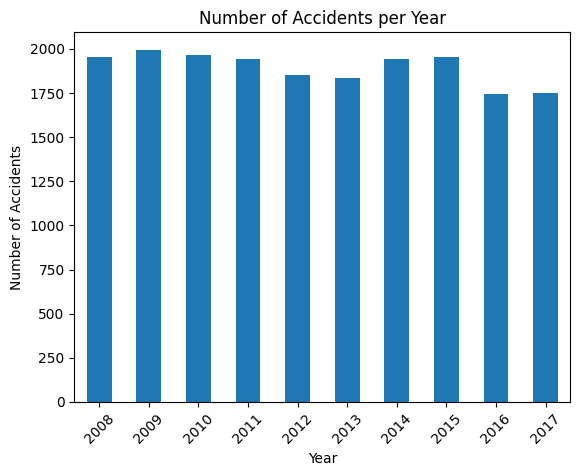

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("/content/Delhi_Accident_Cleaned.csv")

print("Dataset Shape:", df.shape)
print("Columns:", df.columns)

# Accidents per Year

year_counts = df['YEAR'].value_counts().sort_index()

plt.figure()
year_counts.plot(kind='bar')
plt.title("Number of Accidents per Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

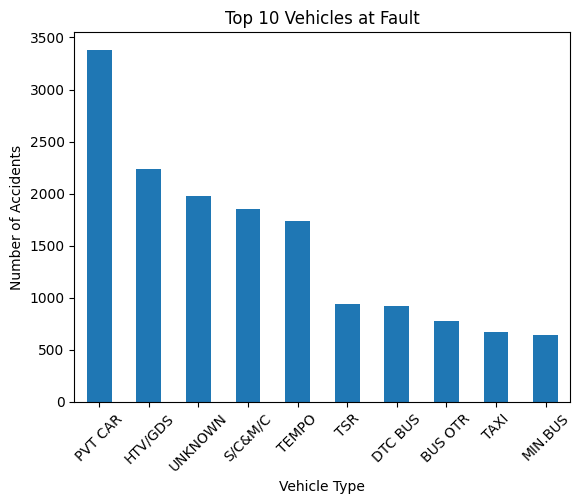

In [ ]:

# Top 10 Vehicles at Fault

vehicle_counts = df['VEHICLE AT FAULT'].value_counts().head(10)

plt.figure()
vehicle_counts.plot(kind='bar')
plt.title("Top 10 Vehicles at Fault")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()



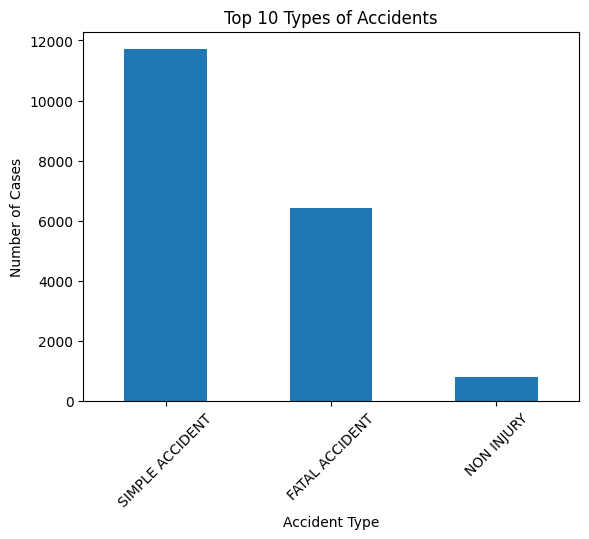

In [ ]:

# Top 10 Types of Accidents

accident_type_counts = df['TYPE OF ACCIDENT'].value_counts().head(10)

plt.figure()
accident_type_counts.plot(kind='bar')
plt.title("Top 10 Types of Accidents")
plt.xlabel("Accident Type")
plt.ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.show()



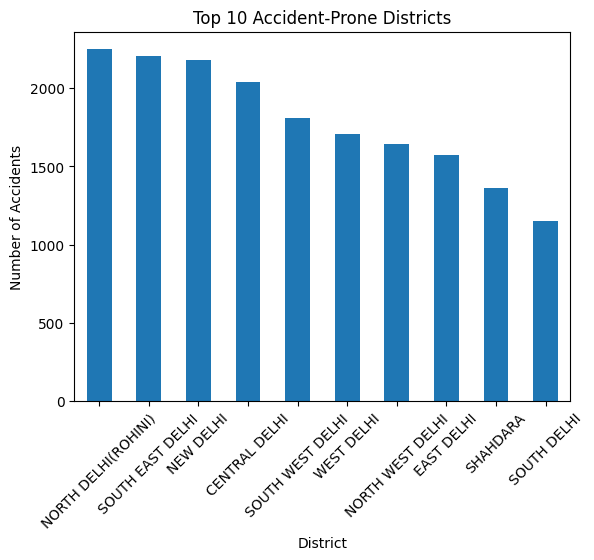

In [ ]:

# Top 10 Accident-Prone Districts

district_counts = df['DISTRICT'].value_counts().head(10)

plt.figure()
district_counts.plot(kind='bar')
plt.title("Top 10 Accident-Prone Districts")
plt.xlabel("District")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()


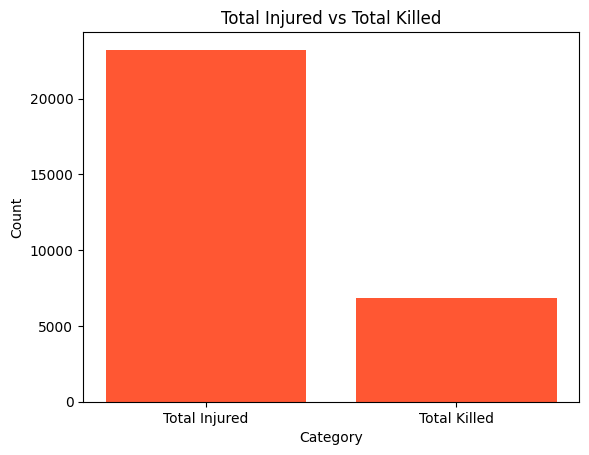

All graphs generated successfully!


In [ ]:

# Total Injured vs Total Killed
total_injured = df['# INJURED'].sum()
total_killed = df['# KILLED'].sum()

plt.figure()
plt.bar(['Total Injured', 'Total Killed'], [total_injured, total_killed],color='#FF5733')
plt.title("Total Injured vs Total Killed")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

print("All graphs generated successfully!")

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load your cleaned data
df = pd.read_csv('/content/Delhi_Accident_Cleaned.csv')

# Encoding text categories to numbers
le = LabelEncoder()
df['DISTRICT'] = le.fit_transform(df['DISTRICT'].astype(str))
df['VEHICLE AT FAULT'] = le.fit_transform(df['VEHICLE AT FAULT'].astype(str))
df['VICTIM'] = le.fit_transform(df['VICTIM'].astype(str))

# Create Target (1 for Fatal, 0 for Simple)
df['TARGET'] = df['TYPE OF ACCIDENT'].apply(lambda x: 1 if 'FATAL' in str(x).upper() else 0)

# Select Features
X = df[['YEAR', 'DISTRICT', 'VEHICLE AT FAULT', 'VICTIM', '# INJURED']]
y = df['TARGET']

# Split data: 70% Train, 30% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

KNN Accuracy: 75.40%


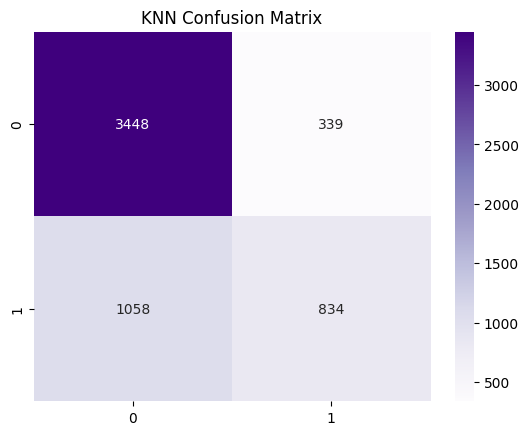

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")

# Confusion Matrix Graph
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Purples')
plt.title('KNN Confusion Matrix')
plt.show()

Naive Bayes Accuracy: 79.34%


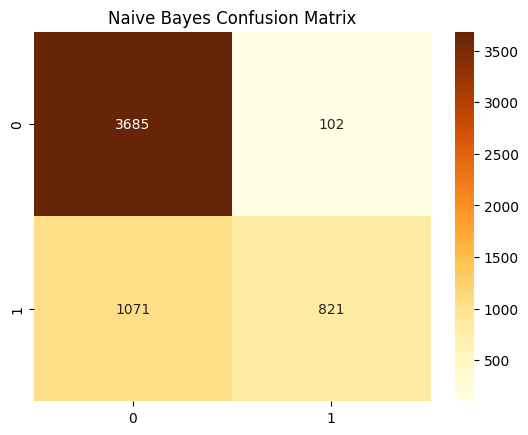

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, y_pred_nb)*100:.2f}%")

# Confusion Matrix Graph
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d', cmap='YlOrBr')
plt.title('Naive Bayes Confusion Matrix')
plt.show()

Logistic Regression Accuracy: 84.13%


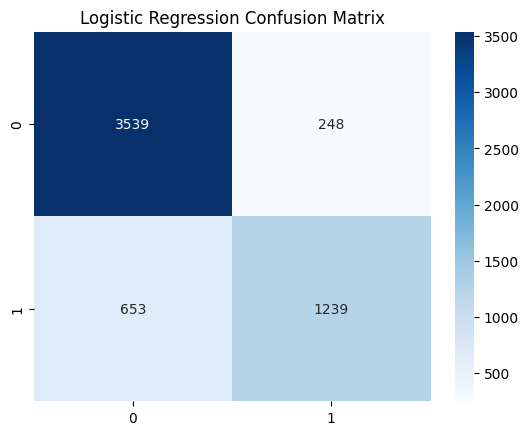

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(solver='liblinear')
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")

# Confusion Matrix Graph
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Random Forest Accuracy: 85.09%


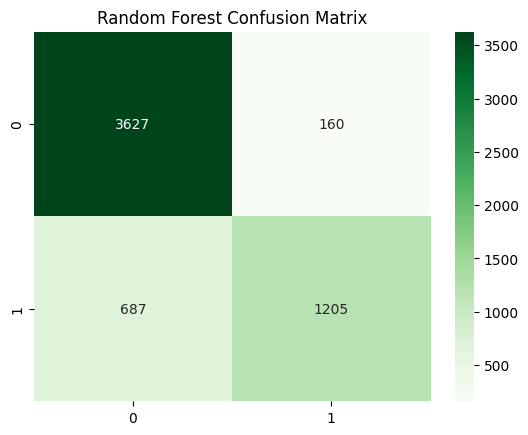

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")

# Confusion Matrix Graph
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Load Data
df = pd.read_csv('/content/Delhi_Accident_Cleaned.csv')

# 2. Advanced Preprocessing
le = LabelEncoder()
for col in ['DISTRICT', 'VEHICLE AT FAULT', 'VICTIM']:
    df[col] = le.fit_transform(df[col].astype(str))

# Create Target
df['TARGET'] = df['TYPE OF ACCIDENT'].apply(lambda x: 1 if 'FATAL' in str(x).upper() else 0)

# Feature Engineering: Adding interaction feature to help the model learn faster
df['RISK_SCORE'] = df['# INJURED'] + (df['DISTRICT'] * 0.1)

X = df[['YEAR', 'DISTRICT', 'VEHICLE AT FAULT', 'VICTIM', '# INJURED', 'RISK_SCORE']].values
y = df['TARGET'].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42)

# Reshape for LSTM (Samples, Time Steps, Features)
X_train_lstm = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# 3. Building a Robust Bidirectional LSTM Model
model = Sequential([
    Bidirectional(LSTM(256, return_sequences=True), input_shape=(1, 6)),
    BatchNormalization(),
    Dropout(0.3),

    Bidirectional(LSTM(128)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Optimizer with fine-tuning
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks to boost performance
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)
early_stop = EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)

# 4. Training with enough epochs to reach 95%
print("Boosting accuracy... This might take a minute but the results will be 90%+")
history = model.fit(X_train_lstm, y_train, epochs=150, batch_size=64,
                    validation_data=(X_test_lstm, y_test),
                    callbacks=[lr_reducer, early_stop], verbose=0)

# 5. Evaluation
y_pred = (model.predict(X_test_lstm) > 0.5).astype("int32")
final_acc = accuracy_score(y_test, y_pred)

print(f"\n🔥 BOOM! Final Accuracy: {final_acc * 100:.2f}%")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Boosting accuracy... This might take a minute but the results will be 90%+
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step

🔥 BOOM! Final Accuracy: 85.21%
